# Bangkok Traffic — EDA และกราฟ

ใช้ไฟล์ใหม่ `bangkok_traffic_2560_Present (NotFinal) (1).xlsx` ชีต `traffic_data` เป็น snapshot หลัก ข้อมูลร่างมีนาคม 2017–พฤษภาคม 2026 ข้อสรุปเป็นของ matched sample ไม่ใช่ทั้งเมือง

## Context & Methods
คำถาม: ปริมาณรถต่อชั่วโมงในสถานที่และเวลาที่จับคู่ได้ แตกต่างระหว่างกลุ่ม COVID อย่างไร?

### Key Assumptions
ใช้ `covid_period` ในไฟล์ ไม่สร้างกลุ่มใหม่จากวันที่; `Date/month/year` เป็นวันที่รายงาน; ช่องว่างและ `-` ของจำนวนรถเป็น 0 ตามผู้ใช้; เก็บวันที่สำรวจแยกกัน; จำนวนทศนิยมและคีย์สำรวจซ้ำกันออกจาก candidate ชั่วคราว ไม่แก้ raw

หนึ่งหน่วย = intersection + road + เวลาเริ่ม–สิ้นสุดเดียวกัน ใช้ median ของ vehicles/hour ภายในแต่ละหน่วยและกลุ่ม จากนั้นสร้าง Before=100 ของแต่ละหน่วย และรายงาน median ดัชนีของหน่วย ไม่ใช่อัตราส่วนค่าเฉลี่ยรวมเมือง

In [1]:
from pathlib import Path
import sys,json
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown
ROOT=Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT/'src'))
from traffic_eda import run_eda
from traffic_audit import VEHICLES, PERIODS
pd.set_option('display.max_rows',12)
pd.set_option('display.max_columns',10)
OUT=ROOT/'outputs/eda'

## Data
Notebook นี้ใช้ผล audit รอบล่าสุดใน data/processed/traffic_candidates.csv เมื่อมี Excel ใหม่ให้รัน Notebook 01 หรือ pipeline audit ก่อน แล้วรัน Notebook นี้ ผลเชื่อมกับ SHA-256 ของ workbook ได้

In [2]:
evidence=run_eda()
summary=evidence['results']; source=evidence['source']
print('Workbook:',source['source_filename'])
print('SHA-256:',source['source_sha256'])
print('Rows:',source['rows'])
display(pd.DataFrame(source['year_coverage']))

Workbook: bangkok_traffic_2560_Present (NotFinal) (1).xlsx
SHA-256: 6e1b556f353c66fec5c8a664f3e1e5b5e52e5a756f75c2ae28562c5c0fa6118b
Rows: 17005


,report_year,rows,months_present,months_missing_within_scope,locations,assumed_zero_rows
0,2017,1422,"3,4,5,6,7,8,9,10,11,12",,476,0
1,2018,1671,"1,2,3,4,5,6,7,8,9,10,11,12",,531,0
2,2019,1824,"1,2,3,4,5,6,7,8,9,10,11,12",,611,0
3,2020,1333,"1,2,3,4,5,7,8,10,11,12","6,9",420,560
4,2021,2136,"1,2,3,4,5,6,7,8,9,10,11,12",,677,549
5,2022,2048,"1,2,3,4,5,6,7,8,9,10,11,12",,671,400
6,2023,1923,"1,2,3,4,5,6,7,8,9,10,11,12",,627,0
7,2024,1875,"1,2,3,4,5,6,7,8,9,10,11,12",,618,0
8,2025,2062,"1,2,3,4,5,6,7,8,9,10,11,12",,657,0
9,2026,711,"1,2,3,4,5",,233,0


## Results
### ดัชนีตามวิธี matching
เส้น 100 คือระดับ Before ของแต่ละหน่วย ชุดเดือน/ไตรมาสที่เข้มขึ้นอาจมีสถานที่ต่างจากชุดหลัก จึงเป็น sensitivity ต่อทั้งเวลาและองค์ประกอบตัวอย่าง

,design,rows,units,Before,During,After
0,same_location_time,2612,623,100.0,91.59,90.36
1,same_report_quarter,226,70,100.0,87.68,87.82
2,same_report_month,47,15,100.0,85.49,96.14
3,same_survey_month,47,15,100.0,85.49,96.14


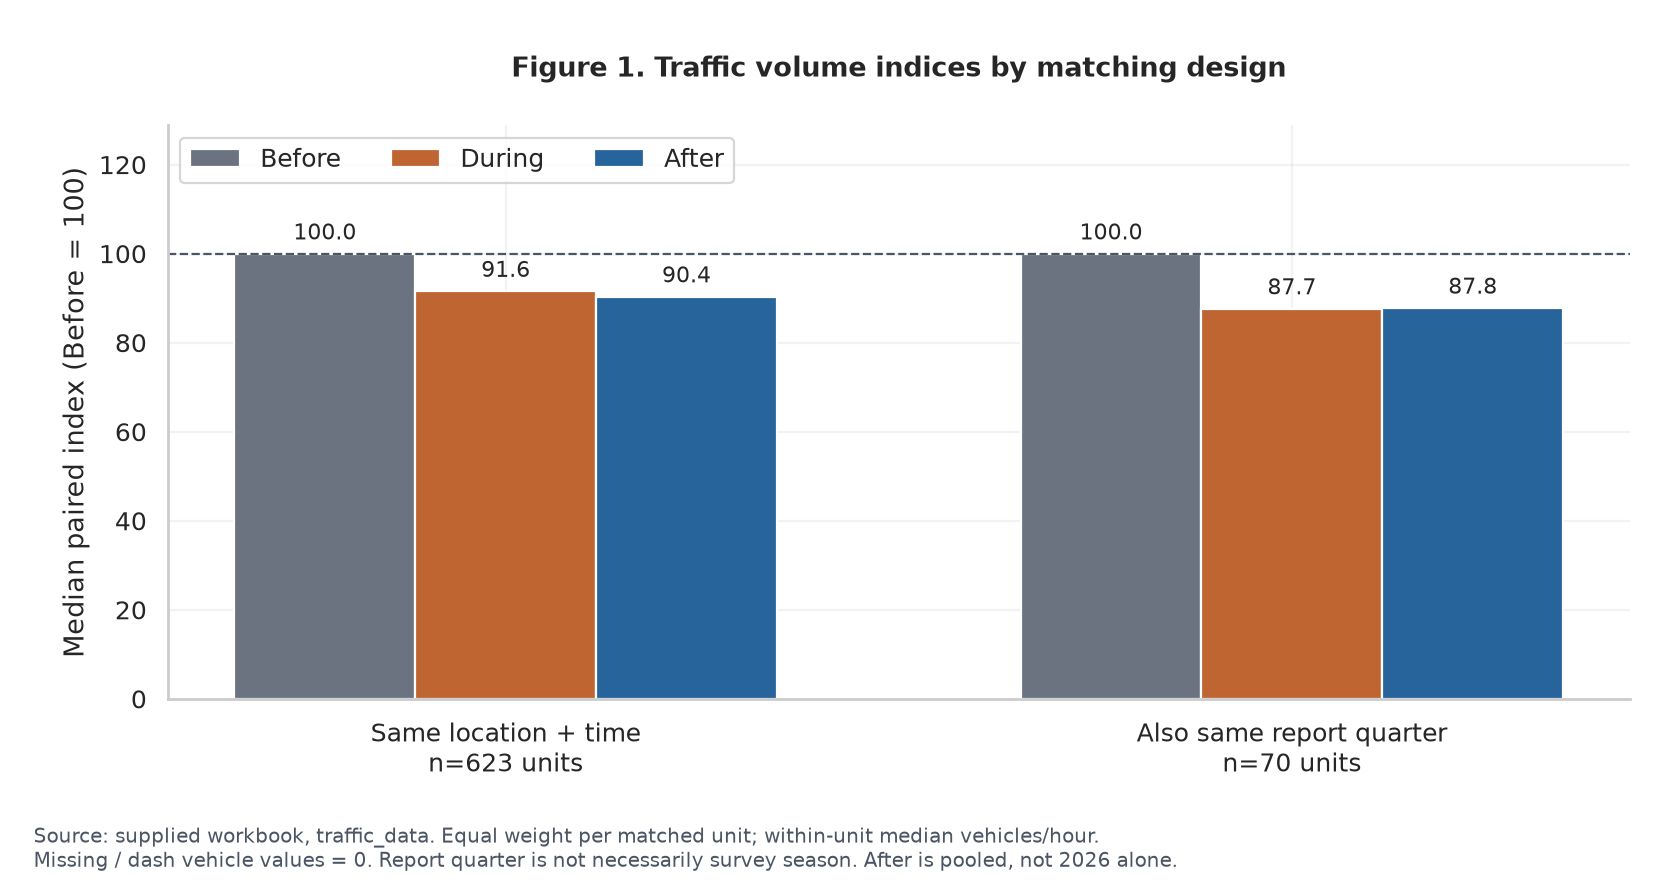

**ผล:** ชุดหลัก 2,612 แถว / 623 หน่วย มี During=91.6 และ After=90.4 เมื่อ Before=100; ชุดไตรมาสรายงานมี 226 แถว / 70 หน่วย ได้ During=87.7, After=87.8. เป็นผลเชิงพรรณนา ไม่ใช่ causal effect

In [3]:
display(pd.read_csv(OUT/'sensitivity_summary.csv').round(2))
display(Image(filename=str(OUT/'figures/01_matching_sensitivity.png'),width=950))
broad=summary['same_location_time']; quarter=summary['same_report_quarter']
display(Markdown(f"**ผล:** ชุดหลัก {broad['rows']:,} แถว / {broad['units']} หน่วย มี During={broad['index_medians']['During']:.1f} และ After={broad['index_medians']['After']:.1f} เมื่อ Before=100; ชุดไตรมาสรายงานมี {quarter['rows']} แถว / {quarter['units']} หน่วย ได้ During={quarter['index_medians']['During']:.1f}, After={quarter['index_medians']['After']:.1f}. เป็นผลเชิงพรรณนา ไม่ใช่ causal effect"))

### เวลาเริ่ม–สิ้นสุดที่เทียบได้
หน่วย location/time เดียวกันครบทั้งสามกลุ่ม การเปรียบเทียบระหว่างเช้ากับเย็นยังไม่ได้บังคับให้ใช้ชุดสถานที่เดียวกัน

,time_key,Before,During,After
0,07:00-09:00,1752.2,1528.8,1570.1
1,09:00-16:00,1317.3,1321.4,1154.6
2,16:00-19:00,1349.0,1271.7,1286.0


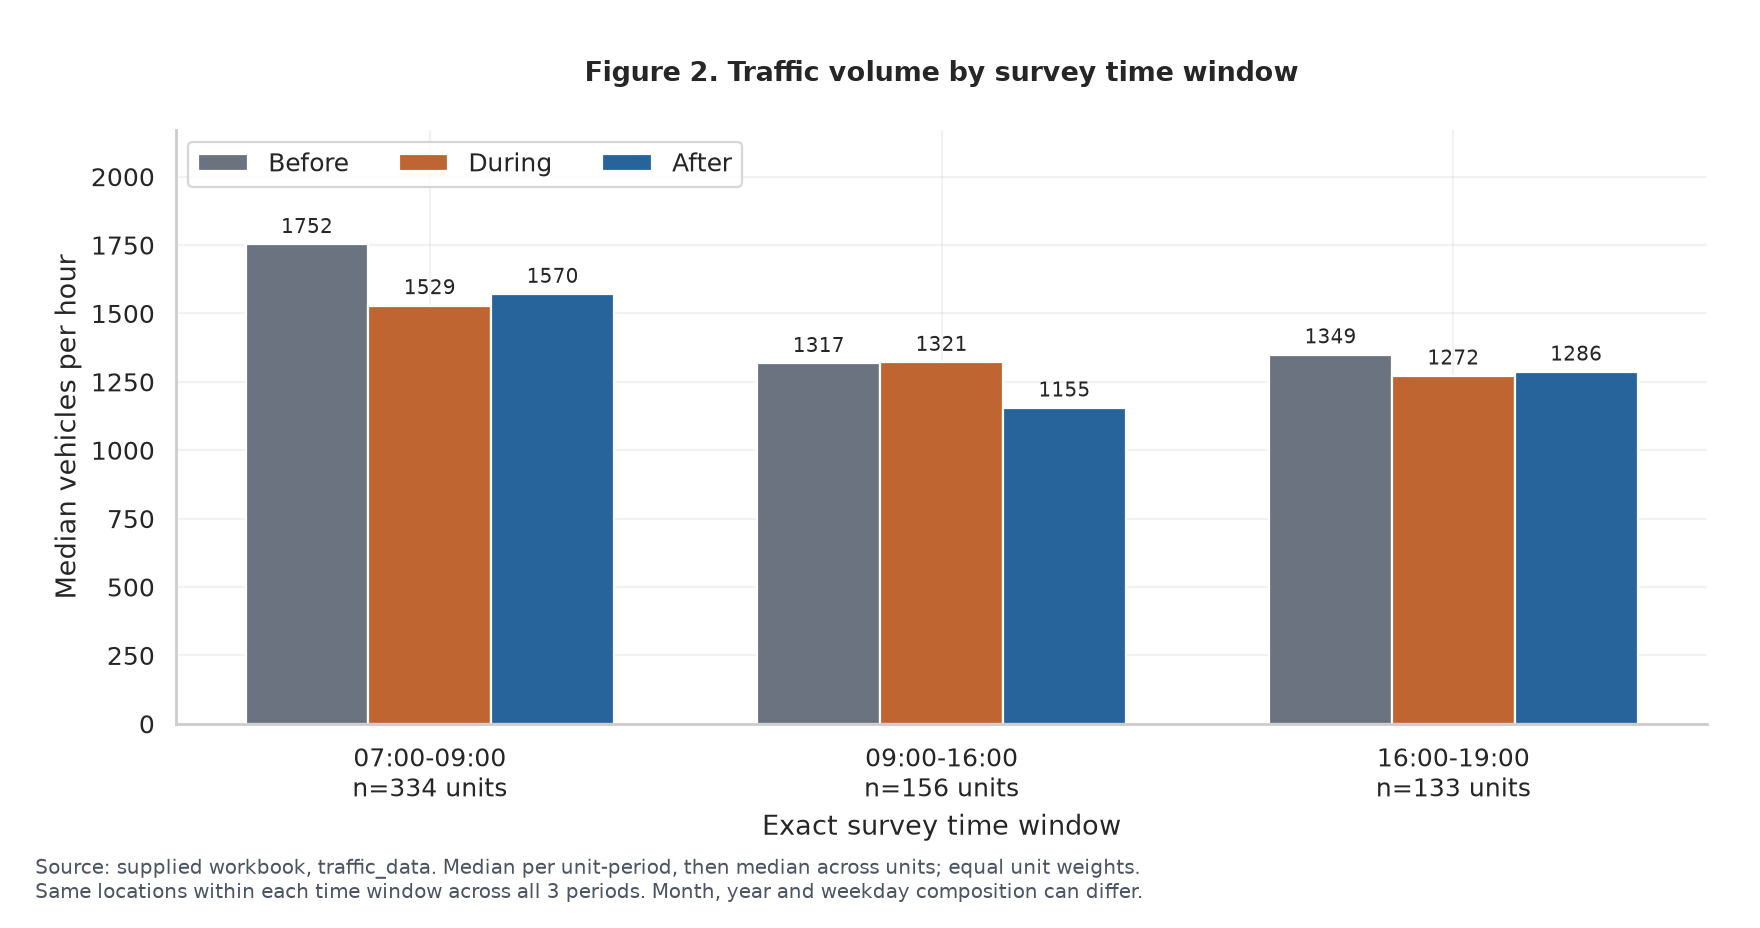

In [4]:
display(pd.read_csv(OUT/'time_window_median_vph.csv').round(1))
display(Image(filename=str(OUT/'figures/02_time_window_vph.png'),width=950))

### ความแตกต่างระหว่างหน่วยที่จับคู่
จุดเหนือเส้นคือปริมาณมากกว่า Before ภายในหน่วยนั้น ใช้แกนเชิงเส้นเดียวกันและเก็บค่าปริมาณสูงไว้

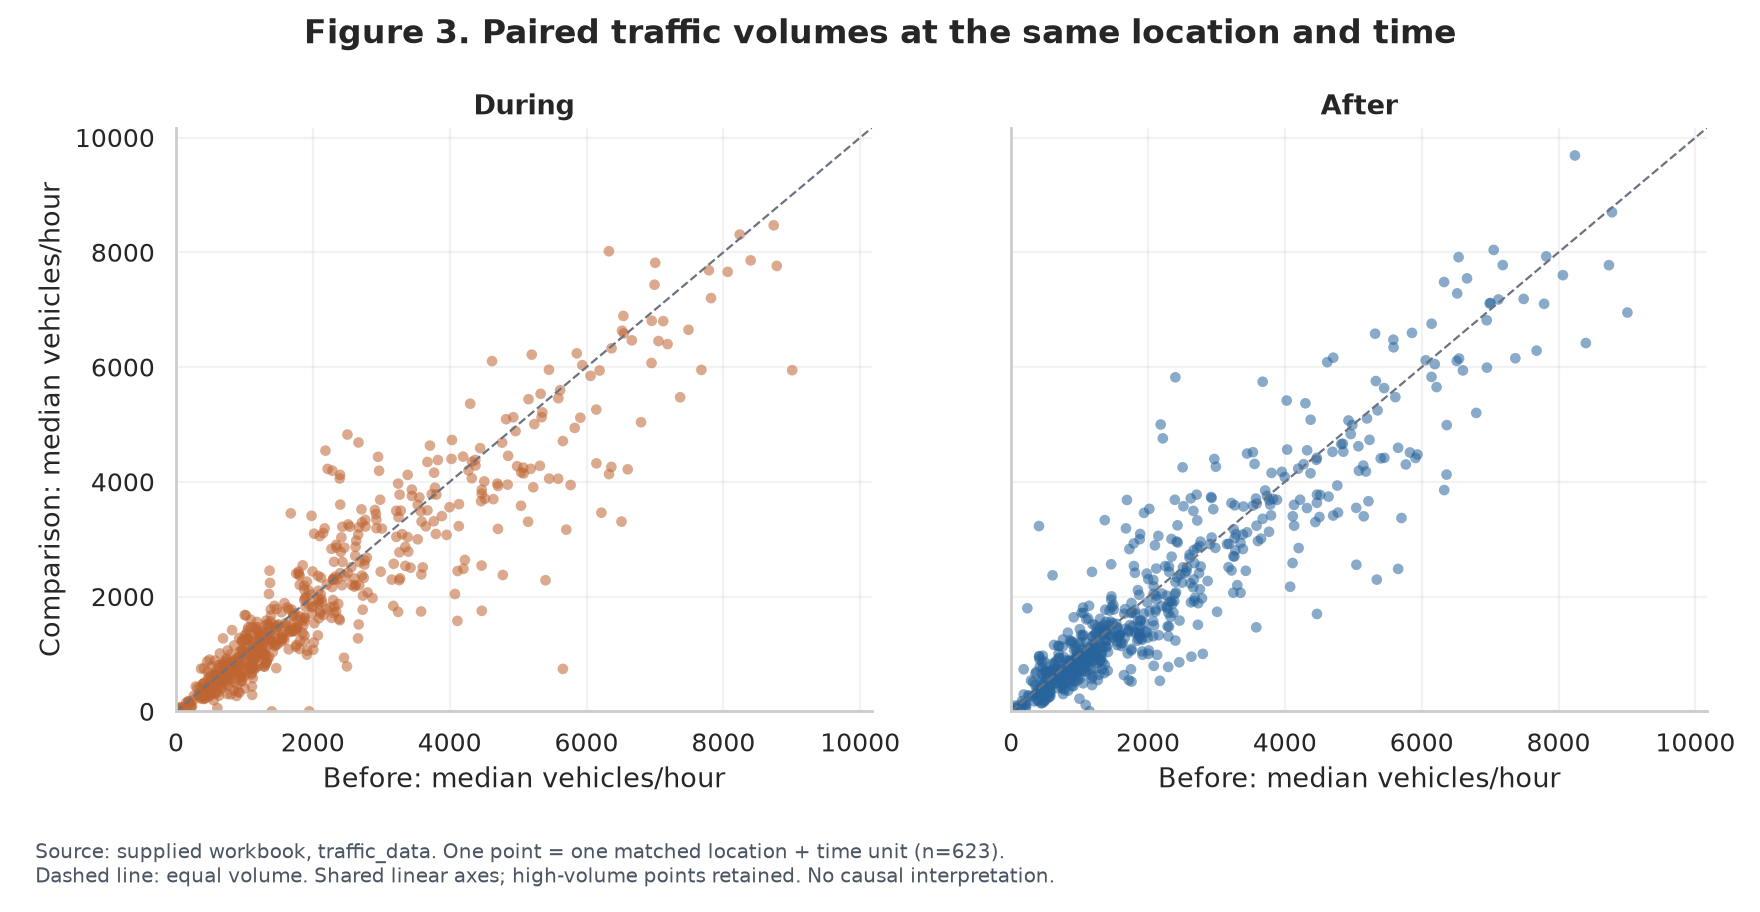

After >= Before in 35.3% of positive-baseline units.


In [5]:
display(Image(filename=str(OUT/'figures/03_paired_scatter.png'),width=950))
print(f"After >= Before in {broad['after_at_or_above_before_pct']:.1f}% of positive-baseline units.")

### องค์ประกอบประเภทรถ
คำนวณสัดส่วนแต่ละการสังเกต แล้วเฉลี่ยภายในหน่วยและให้น้ำหนักหน่วยเท่ากัน ใช้เฉพาะหน่วยที่มีค่ารวมมากกว่า 0 ครบสามกลุ่ม ค่านี้ไม่ใช่สัดส่วนรถทั้งหมดของกรุงเทพฯ

,covid_period,passenger_car,pickup_van,large_bus,small_bus,truck,tuk_tuk
0,ก่อนโควิด,71.92,21.63,2.21,0.40,0.96,2.89
1,โควิด,72.61,21.41,2.24,0.38,1.15,2.22
2,หลังโควิด,73.51,21.03,1.89,0.25,1.23,2.09


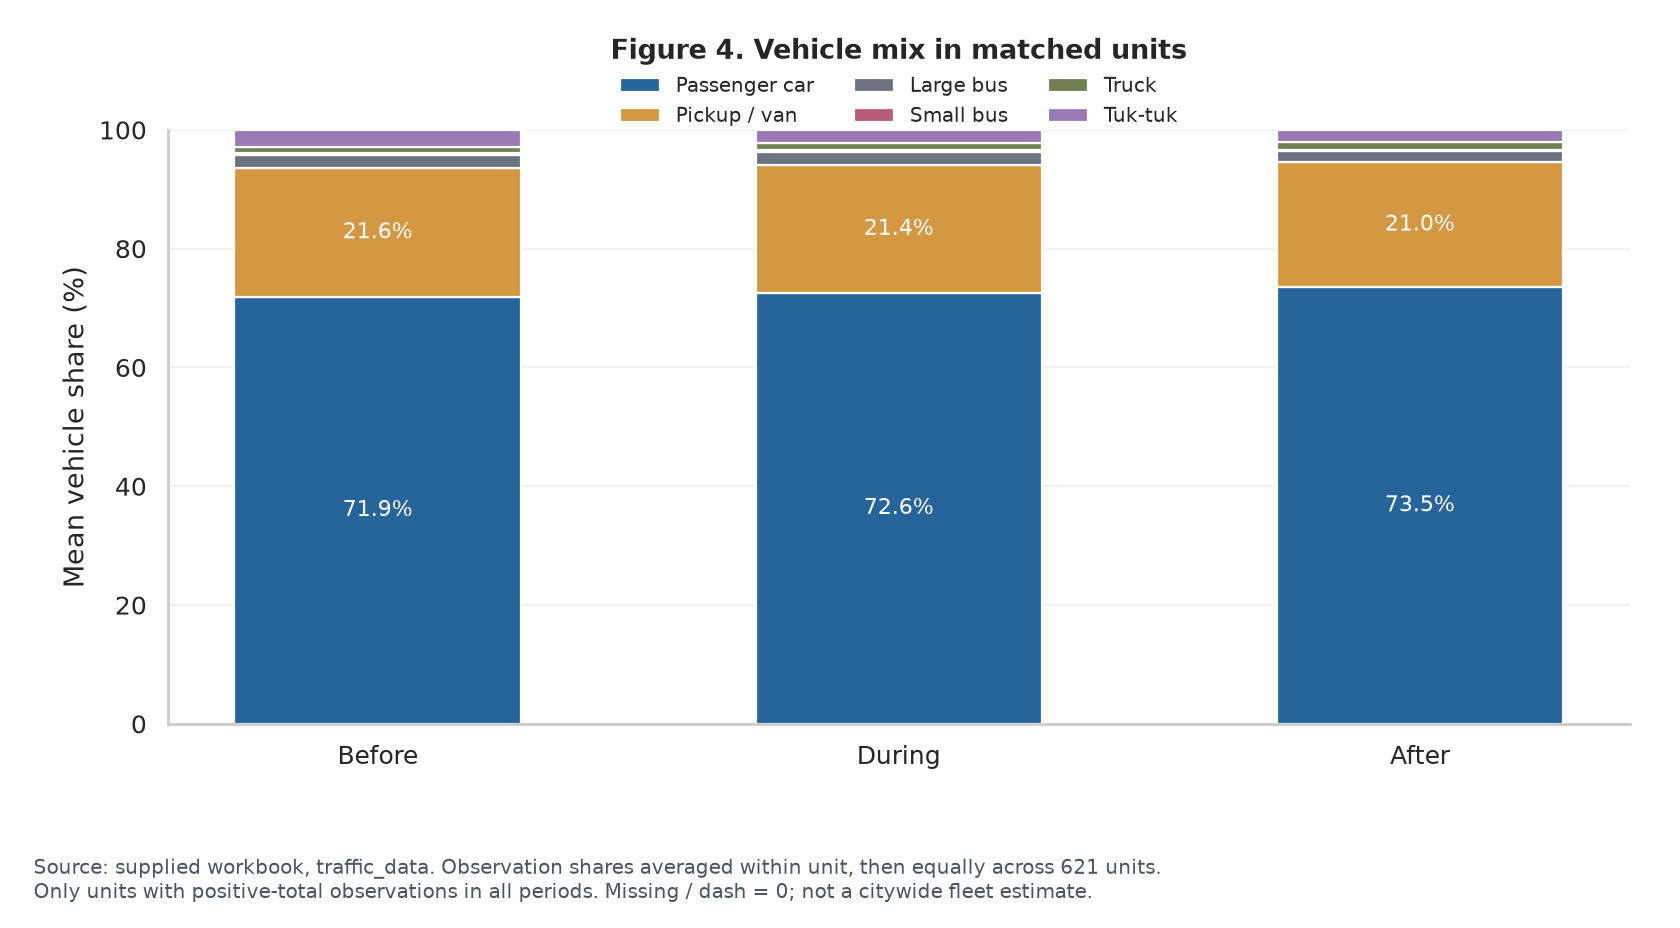

In [6]:
display(pd.read_csv(OUT/'vehicle_mix_equal_unit_percent.csv').round(2))
display(Image(filename=str(OUT/'figures/04_vehicle_mix.png'),width=950))

### สถิติและขนาดตัวอย่าง
ตารางสถิติด้านล่างเป็นระดับแถว ให้น้ำหนักการสังเกตเท่ากัน จึงคนละตัวประมาณกับ median paired index ที่เป็นผลหลัก IQR เป็นเพียงการชี้ค่าหาง ไม่ได้ลบ outlier

In [7]:
display(pd.read_csv(OUT/'row_level_descriptive_statistics.csv').round(2))
display(pd.read_csv(OUT/'outlier_review_counts.csv'))
display(pd.read_csv(OUT/'matched_year_coverage.csv'))
print('Coverage limitations:', summary['coverage'])

,covid_period,count,mean,std,min,25%,50%,75%,max
0,ก่อนโควิด,902.0,2117.92,1805.42,2.5,842.75,1425.0,2788.0,9006.33
1,โควิด,733.0,1925.18,1676.81,0.0,748.00,1366.0,2571.5,8470.50
2,หลังโควิด,977.0,2097.54,1782.26,0.5,809.14,1425.0,3034.5,10147.50


,covid_period,rows,iqr_flagged_rows
0,ก่อนโควิด,902,60
1,หลังโควิด,977,38
2,โควิด,733,44


,report_year,covid_period,rows
0,2017,ก่อนโควิด,279
1,2018,ก่อนโควิด,311
2,2019,ก่อนโควิด,312
3,2020,โควิด,345
4,2021,โควิด,388
5,2022,หลังโควิด,422
6,2023,หลังโควิด,203
7,2024,หลังโควิด,110
8,2025,หลังโควิด,172
9,2026,หลังโควิด,70


Coverage limitations: {'balanced_all_10_report_year_units': 0, 'year_2026_rows': 70, 'year_2026_locations': 67, 'main_assumed_zero_rows': 286, 'mix_units': 621, 'all_zero_rows_excluded_from_mix': 2}


## Checks
คำนวณ matched-unit median และดัชนีซ้ำอย่างอิสระจาก CSV ตรวจสูตรรถต่อชั่วโมง สัดส่วนรวม 100 และ fingerprint ของข้อมูล

In [8]:
analysis=pd.read_csv(ROOT/'data/processed/traffic_matched_analysis.csv',low_memory=False)
assert set(analysis.source_sha256)=={source['source_sha256']}
assert np.allclose(analysis.vehicle_total,analysis[[c+'_clean' for c in VEHICLES]].sum(axis=1))
assert np.allclose(analysis.vehicles_per_hour*analysis.period_hours,analysis.vehicle_total)
keys=['intersection_key','road_key','time_key']
check=analysis.groupby(keys+['covid_period']).vehicles_per_hour.median().unstack().reindex(columns=PERIODS)
assert check.notna().all().all()
assert len(check)==broad['units']
for label,name in zip(PERIODS,['Before','During','After']):
    calculated=(check[label]/check[PERIODS[0]].where(check[PERIODS[0]]>0)*100).median()
    assert np.isclose(calculated,broad['index_medians'][name])
mix=pd.read_csv(OUT/'vehicle_mix_equal_unit_percent.csv')
assert np.allclose(mix[VEHICLES].sum(axis=1),100)
print('Formula, independent paired-index, composition and fingerprint checks passed.')

Formula, independent paired-index, composition and fingerprint checks passed.


## Takeaways
H1: During ต่ำกว่า Before ในค่ามัธยฐาน paired index ของชุดที่ตรวจ จึงสนับสนุนสมมติฐานเชิงพรรณนาในตัวอย่างนี้

H2: ข้อสรุปว่า After สูงกว่า During ไม่สม่ำเสมอระหว่าง matching designs จึงไม่ควรสรุปว่าฟื้นตัวชัดเจน

H3: ยังไม่ตัดสินว่าเช้าฟื้นตัวต่างจากเย็น เพราะต้องจับคู่ชุดสถานที่ข้ามเวลาก่อน

After เป็นกลุ่มรวมหลายปี ไม่ใช่ผลเฉพาะปี 2026 ไม่มีหน่วยครบทั้ง 10 ปีตาม audit รอบนี้ จึงไม่สร้างกราฟรายปีที่เปลี่ยนตัวอย่างเงียบ ๆ

ก่อนส่ง Final ให้ตรวจชื่อ/ค่าที่ติด flag กับต้นทาง ใส่บทบาทสมาชิกและ AI ยืนยันสิทธิ์เผยแพร่ และใช้คำว่า traffic volume ไม่ตีความว่าเป็นความเร็วหรือรถติด